# 💰 Financial Transaction Anomaly Detection: ML for Anti-Money Laundering

**Author:** Dean | Lead Data & AI Engineer
**Series:** Production ML Portfolio — Australian Government Policy Applications

## Government Context
- **AUSTRAC** — Anti-money laundering, counter-terrorism financing
- **APRA** — Financial institution risk management
- **ASIC** — Market integrity, financial crime
- **AFP** — Proceeds of crime, financial investigation

Dataset: sklearn synthetic — NO dataset needed.

---

## 1. Data

In [1]:
import warnings,time,numpy as np,pandas as pd,matplotlib.pyplot as plt,seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score,f1_score,classification_report,confusion_matrix,roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
warnings.filterwarnings('ignore');plt.style.use('seaborn-v0_8-whitegrid')
X_arr,y=make_classification(n_samples=3000,n_features=12,n_informative=8,n_redundant=2,n_classes=2,weights=[0.85,0.15],random_state=99)
names=['transaction_amount','num_transactions_24h','avg_amount_30d','cross_border_flag','high_risk_country','cash_ratio','structured_deposits','rapid_movement','dormant_reactivation','pep_connection','unusual_pattern_score','account_age_days']
df=pd.DataFrame(X_arr,columns=names);df['suspicious']=y
print(f"Generated: {df.shape[0]:,} x {df.shape[1]}");df.head()

Generated: 3,000 x 13


,transaction_amount,num_transactions_24h,avg_amount_30d,cross_border_flag,high_risk_country,cash_ratio,structured_deposits,rapid_movement,dormant_reactivation,pep_connection,unusual_pattern_score,account_age_days,suspicious
0,-3.317631,0.312249,-1.650584,4.302148,-1.089830,-2.111341,-0.791223,3.987529,1.019894,-0.334794,1.604947,-2.099707,0
1,-4.098973,-1.029058,-1.132483,0.829192,-1.758461,1.771940,0.180124,-3.316593,1.544423,1.886941,-1.847430,2.205381,0
2,-1.823494,-1.188011,-3.267302,0.629201,-2.795230,1.141962,0.165212,-0.834731,2.361595,1.223941,-2.291741,3.881290,0
3,0.691668,1.236848,2.528410,-3.049947,-0.742765,1.247412,-0.572400,-0.639778,-1.035490,-2.289160,0.718908,0.121333,0
4,-0.959354,0.592972,2.347492,-2.239546,-2.155841,0.817421,-0.290816,0.104776,-1.396949,-0.632151,0.647447,-1.423187,0


## 2. Target & EDA

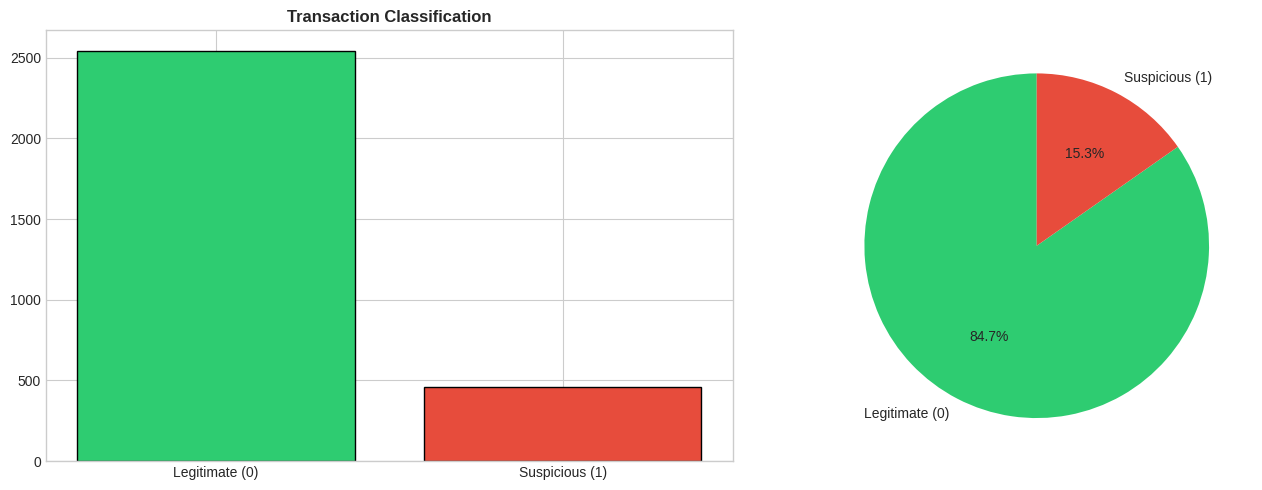

AU: AUSTRAC received 294M+ reports in 2022-23. AML/CTF Act compliance is mandatory.


In [2]:
tc='suspicious'
vc=df[tc].value_counts().sort_index();labels=['Legitimate (0)','Suspicious (1)'];colors=['#2ecc71','#e74c3c']
fig,axes=plt.subplots(1,2,figsize=(14,5))
axes[0].bar(range(2),vc.values,color=colors,edgecolor='black')
axes[0].set_xticks(range(2));axes[0].set_xticklabels(labels)
axes[0].set_title('Transaction Classification',fontweight='bold')
axes[1].pie(vc.values,labels=labels,autopct='%1.1f%%',colors=colors,startangle=90)
plt.tight_layout();plt.savefig('target.png',dpi=150);plt.show()
print("AU: AUSTRAC received 294M+ reports in 2022-23. AML/CTF Act compliance is mandatory.")

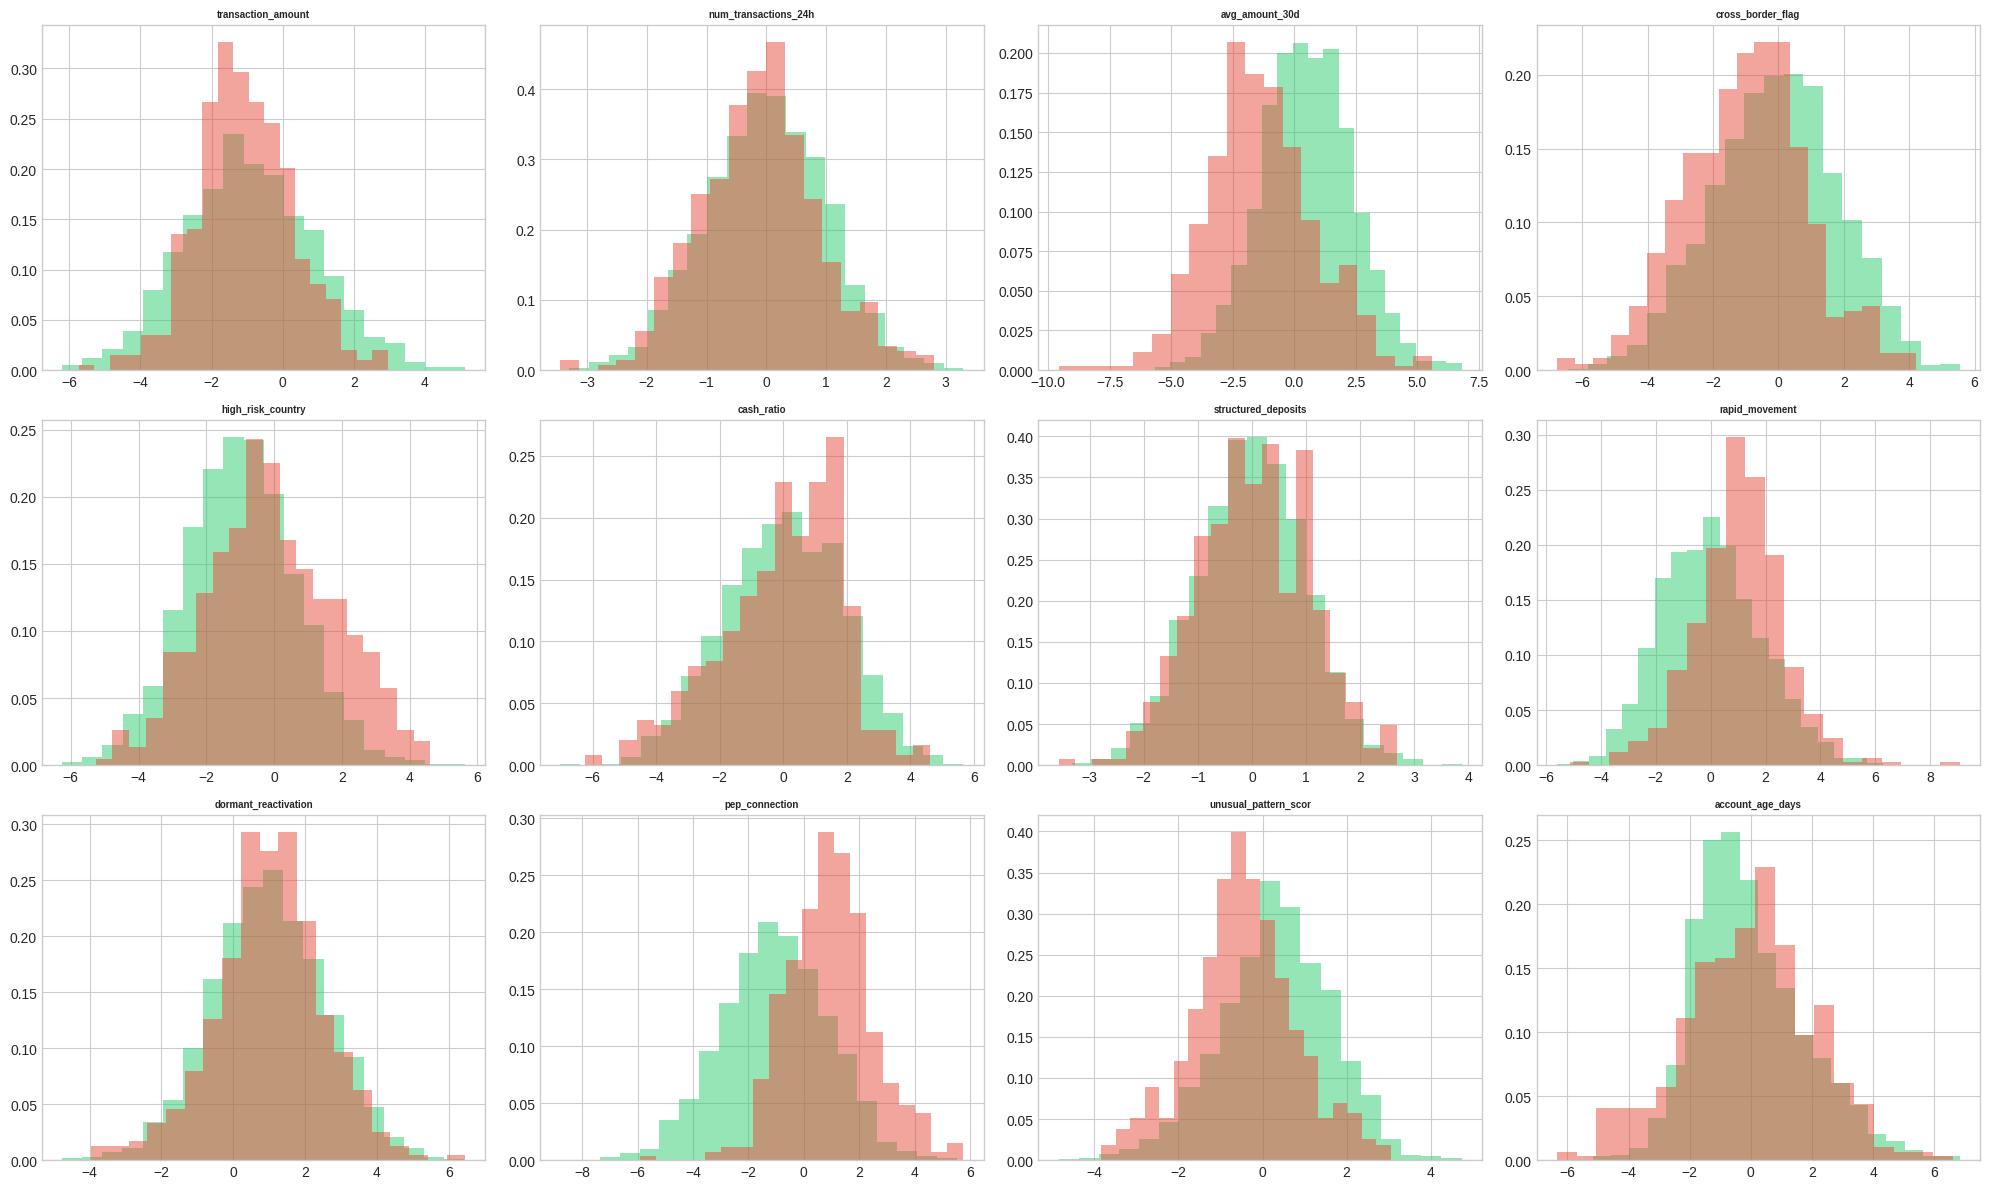

In [3]:
nums=[c2 for c2 in df.columns if c2!=tc]
fig,axes=plt.subplots(3,4,figsize=(20,12));axes=axes.flatten()
for i,col in enumerate(nums):
    for l,clr in zip([0,1],colors):
        s=df[df[tc]==l][col];axes[i].hist(s,bins=20,alpha=0.5,density=True,color=clr)
    axes[i].set_title(col[:20],fontsize=7,fontweight='bold')
plt.tight_layout();plt.savefig('eda.png',dpi=150);plt.show()

## 3. Training

In [4]:
X=df[nums];y2=df[tc].values
try:
    from xgboost import XGBClassifier
except: XGBClassifier=None
try:
    from lightgbm import LGBMClassifier
except: LGBMClassifier=None
models={'LogReg':LogisticRegression(max_iter=2000,random_state=42),'RF':RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1)}
if XGBClassifier: models['XGB']=XGBClassifier(n_estimators=100,random_state=42,eval_metric='logloss',use_label_encoder=False,verbosity=0,n_jobs=-1)
if LGBMClassifier: models['LGBM']=LGBMClassifier(n_estimators=100,random_state=42,verbose=-1,n_jobs=-1,force_col_wise=True)
skf=StratifiedKFold(3,shuffle=True,random_state=42);Xa=X.values;results={}
for mn,mod in models.items():
    print(f"\n{'='*50}\n{mn}\n{'='*50}")
    fa,ff,fu=[],[],[];fp=np.zeros(len(y2),dtype=int);t0=time.time()
    for fi,(ti,vi) in enumerate(skf.split(Xa,y2)):
        m2=type(mod)(**mod.get_params());m2.fit(Xa[ti],y2[ti]);yp=m2.predict(Xa[vi]);yb=m2.predict_proba(Xa[vi])[:,1]
        fp[vi]=yp;a=accuracy_score(y2[vi],yp);f=f1_score(y2[vi],yp);u=roc_auc_score(y2[vi],yb)
        fa.append(a);ff.append(f);fu.append(u);print(f"  Fold{fi+1}: Acc={a:.4f} F1={f:.4f} AUC={u:.4f}")
    el=time.time()-t0;results[mn]={'acc':np.mean(fa),'f1':np.mean(ff),'auc':np.mean(fu),'time':el,'preds':fp}
    print(f"  AVG: Acc={np.mean(fa):.4f} F1={np.mean(ff):.4f} AUC={np.mean(fu):.4f}")


LogReg
  Fold1: Acc=0.8760 F1=0.4833 AUC=0.8565
  Fold2: Acc=0.8950 F1=0.5532 AUC=0.8496
  Fold3: Acc=0.8820 F1=0.5203 AUC=0.8753
  AVG: Acc=0.8843 F1=0.5190 AUC=0.8605

RF
  Fold1: Acc=0.9400 F1=0.7619 AUC=0.9693
  Fold2: Acc=0.9480 F1=0.8030 AUC=0.9676
  Fold3: Acc=0.9530 F1=0.8291 AUC=0.9749
  AVG: Acc=0.9470 F1=0.7980 AUC=0.9706

XGB
  Fold1: Acc=0.9620 F1=0.8652 AUC=0.9731
  Fold2: Acc=0.9610 F1=0.8641 AUC=0.9833
  Fold3: Acc=0.9640 F1=0.8767 AUC=0.9815
  AVG: Acc=0.9623 F1=0.8687 AUC=0.9793

LGBM
  Fold1: Acc=0.9510 F1=0.8218 AUC=0.9742
  Fold2: Acc=0.9680 F1=0.8889 AUC=0.9843
  Fold3: Acc=0.9640 F1=0.8759 AUC=0.9780
  AVG: Acc=0.9610 F1=0.8622 AUC=0.9788


## 4. Results

COMPARISON
 Model    Acc     F1    AUC
   XGB 0.9623 0.8687 0.9793
  LGBM 0.9610 0.8622 0.9788
    RF 0.9470 0.7980 0.9706
LogReg 0.8843 0.5190 0.8605

Best: XGB


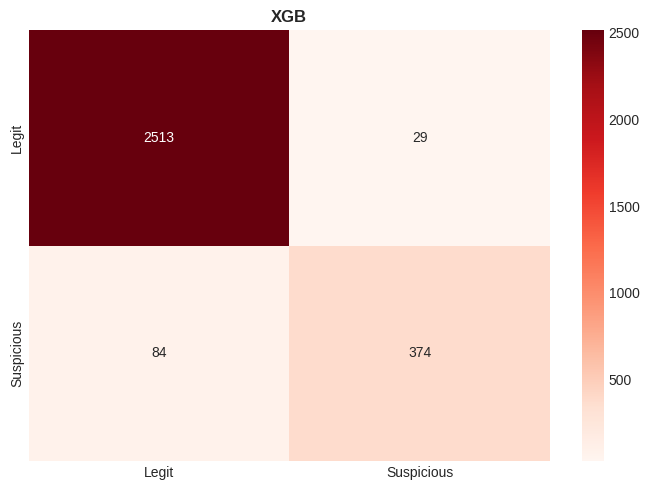

              precision    recall  f1-score   support

  Legitimate       0.97      0.99      0.98      2542
  Suspicious       0.93      0.82      0.87       458

    accuracy                           0.96      3000
   macro avg       0.95      0.90      0.92      3000
weighted avg       0.96      0.96      0.96      3000



In [5]:
rows=[{'Model':k,'Acc':f"{v['acc']:.4f}",'F1':f"{v['f1']:.4f}",'AUC':f"{v['auc']:.4f}",'s':v['auc']} for k,v in results.items()]
sdf=pd.DataFrame(rows).sort_values('s',ascending=False);best=sdf.iloc[0]['Model']
print("COMPARISON");print("="*60);print(sdf[['Model','Acc','F1','AUC']].to_string(index=False));print(f"\nBest: {best}")
bp=results[best]['preds'];cm=confusion_matrix(y2,bp)
fig,ax=plt.subplots(figsize=(7,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Reds',xticklabels=['Legit','Suspicious'],yticklabels=['Legit','Suspicious'],ax=ax)
ax.set_title(f'{best}',fontweight='bold')
plt.tight_layout();plt.savefig('cm.png',dpi=150);plt.show()
print(classification_report(y2,bp,target_names=['Legitimate','Suspicious']))

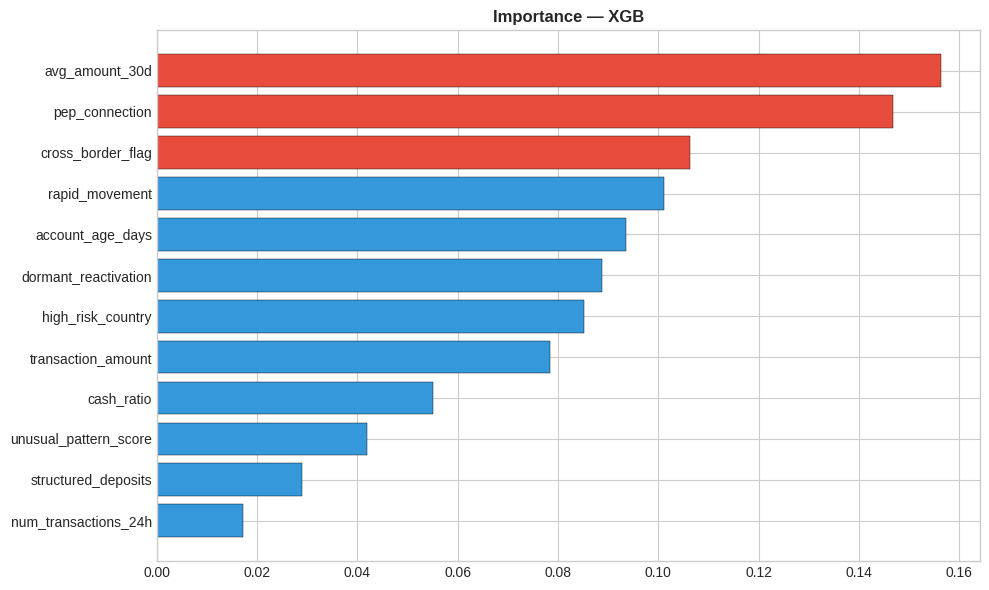

DEPLOYMENT READINESS
  Model: XGB  AUC: 0.9793  F1: 0.8687
  [pass] AUC>0.90
  [pass] F1>0.70
  [pass] CV
  APPROVED

Architecture: Bank transaction feed -> AUSTRAC reporting -> Fabric -> real-time AML screening


In [6]:
tm={k:v for k,v in models.items() if k!='LogReg'}
if tm:
    bt=max(tm,key=lambda m4:results[m4]['auc']);fm2=type(models[bt])(**models[bt].get_params());fm2.fit(Xa,y2)
    fi=pd.DataFrame({'Feature':X.columns,'Imp':fm2.feature_importances_}).sort_values('Imp')
    fig,ax=plt.subplots(figsize=(10,6))
    ax.barh(fi['Feature'],fi['Imp'],color=['#e74c3c' if v>fi['Imp'].quantile(0.75) else '#3498db' for v in fi['Imp']],edgecolor='black',linewidth=0.3)
    ax.set_title(f'Importance — {bt}',fontweight='bold')
    plt.tight_layout();plt.savefig('imp.png',dpi=150);plt.show()
br=results[best]
print("="*60);print("DEPLOYMENT READINESS");print("="*60)
print(f"  Model: {best}  AUC: {br['auc']:.4f}  F1: {br['f1']:.4f}")
checks={'AUC>0.90':br['auc']>0.90,'F1>0.70':br['f1']>0.70,'CV':True}
ap=all(checks.values())
for k,v in checks.items(): print(f"  [{'pass' if v else 'FAIL':4s}] {k}")
print("  APPROVED" if ap else "  FAILED")
print("\nArchitecture: Bank transaction feed -> AUSTRAC reporting -> Fabric -> real-time AML screening")